# Correlation of POP2 Predictions for Round 2

In [1]:
import pandas as pd
# pop2_preds = pd.read_csv('notebooks/jacob/results/r1_ethyvalerolactam_predicted_activity.csv')
# pop2_preds = pd.read_csv('notebooks/jacob/results/r1_ethyvalerolactam_stacked_predicted_activity.csv')
pop2_preds = pd.read_csv('notebooks/jacob/results/E250522_stacked_pairdropout_300epoch_predicted_activity.csv')
# pop2_preds = pd.read_csv('notebooks/jacob/results/E250522_stacked_pairdropout_300epoch_20members_predicted_activity.csv')
pop2_preds = pop2_preds.set_index('seq_id')
model_columns = [c for c in pop2_preds.columns if c.startswith('model_')]
pop2_preds[model_columns] = pop2_preds[model_columns].apply(lambda x: (x - x.mean()) / x.std(), axis=0)

UCB_BETA = 0.0

pop2_preds['has_F61'] = pop2_preds.index.str.contains('F61')
pop2_preds['mean'] = pop2_preds[model_columns].mean(axis=1)
pop2_preds['stddev'] = pop2_preds[model_columns].std(axis=1)
pop2_preds['score'] = pop2_preds['mean'] + UCB_BETA * pop2_preds['stddev']

pop2_preds = pop2_preds.sort_values('score', ascending=False)


# Botorch

In [30]:
import torch
import pandas as pd
from botorch.models.ensemble import EnsembleModel
from torch import Tensor
from botorch.acquisition import qUpperConfidenceBound
from botorch.optim import optimize_acqf_discrete

# pop2_df: index = seq_id, columns = model_1 … model_20 (float scores)
QUCB_BETA  = 4.0                      # exploration weight – tune as you like
Q     = 24                      # slate size

pop2_subset = pop2_preds[model_columns].head(10000).sample(frac=1.0)

N, S = pop2_subset.shape          # N ≈ 20 000 ; S = 20 models
assert S == len(model_columns), "Expect one column per model"

# tensor shape  (S, N)  == (ensemble, candidates)
pred_tensor = torch.tensor(pop2_preds[model_columns].values.T, dtype=torch.float32)  # (20, N)
seq_ids     = pop2_preds[model_columns].index.to_numpy()                             # (N,)
choices = torch.arange(N, dtype=torch.long).unsqueeze(-1)   # (N, 1)


class PrecomputedEnsemble(EnsembleModel):
    def __init__(self, preds: Tensor):
        """
        preds : (S, N)   where S = # models (20) and N = # sequences
        """
        super().__init__()
        self.register_buffer("preds", preds)   # not trainable
        self._num_outputs = 1                  # tells BoTorch that m = 1

    def forward(self, X: Tensor) -> Tensor:
        """
        Parameters:
        X (Tensor) - A batch_shape x n x d-dim input tensor X.

        Returns
        :
        A batch_shape x s x n x m-dimensional output tensor where s is the size of the ensemble.
        """
        # print(f'X.shape: {X.shape}, expect batch_shape x q (24) x 1')
        idx = X.long().squeeze(-1)             # (..., q)
        out = self.preds[:, idx]               # (S, ..., q)
        # print(f'out.shape: {out.shape}, want batch_shape x ensemble_size x q (24) x 1')
        out = out.movedim(0, 1)               # (..., S, q)
        # print(f'out.shape: {out.shape}, want batch_shape x ensemble_size x q (24) x 1')
        out = out.unsqueeze(-1)               # (..., S, q, 1)
        # print(f'out.shape: {out.shape}, want batch_shape x ensemble_size x q (24) x 1')
        return out

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device('cpu')

model = PrecomputedEnsemble(pred_tensor.to(device)).eval()
acqf  = qUpperConfidenceBound(model=model, beta=QUCB_BETA)

cands, _ = optimize_acqf_discrete(
    acq_function   = acqf,
    choices        = choices.to(device),   # (N, 1)
    q              = Q,
    # sequential     = True,                 # greedy but uses X_pending
    max_batch_size = 2048                  # avoid CUDA OOM
)


KeyboardInterrupt: 

# qUCB

In [94]:
QUCB_BETA = 3.0    # UCB exploration weight
Q         = 24     # slate size

# pop2_df: index = seq_id, columns = model_1 … model_20 (float scores)
pop2_subset = pop2_preds[model_columns].head(1000)
pred_tensor = torch.tensor(
    pop2_subset.values.T, dtype=torch.float32
)  # (S, N) = (ensemble, candidates)
seq_ids = pop2_subset.index.to_numpy()  # (N,)

S, N = pred_tensor.shape
assert S == len(model_columns)

# compute prior means, deviations, and full covariance
means = pred_tensor.mean(dim=0)          # (N,)
devs  = pred_tensor - means              # (S, N)
# sample‐covariance matrix (N×N):
Cov   = (devs.T @ devs) / S              # (N, N)
vars  = Cov.diag()                       # (N,)

# greedy Kriging‐Believer slate selection (see https://www.cs.ubc.ca/labs/algorithms/EARG/stack/2010_CI_Ginsbourger-ParallelKriging.pdf)
selected = []

for _ in range(Q):
    # 1) marginal UCB scores
    ucb = means + QUCB_BETA * vars.sqrt()        # (N,)
    if selected:
        ucb[selected] = -float("inf")            # mask out already‐picked

    # 2) pick best
    idx = int(ucb.argmax().item())
    selected.append(idx)

    # 3) fantasy‐conditioning where you imagine that you pick that sequence: Schur complement to zero covariances with idx (same as covariance thing i wrote a bit back)
    cov_i = Cov[:, idx].clone()                  # (N,)
    v_i   = vars[idx].item()                     # scalar Var(x_idx)
    # Cov_new = Cov - (cov_i outer cov_i) / Var_i
    Cov   = Cov - cov_i.unsqueeze(1) * cov_i.unsqueeze(0) / v_i
    vars  = Cov.diag()                           # update variances

#  map back to your sequence IDs
chosen_seq_ids = seq_ids[selected]               # length Q
print("Chosen slate (seq_ids):", chosen_seq_ids)

Chosen slate (seq_ids): ['G429R_R512E' 'M320R_G429R' 'H8K_G429R' 'Y405R_G429R' 'H8K_Q237E'
 'H8R_G429R' 'G255R_G429R' 'M320R_T390R' 'H8Q_G429R' 'G429R_T473E'
 'E251P_G429R' 'E42R_G429R' 'S336R_G429R' 'D46R_G429R' 'E251R_G429R'
 'D321P_G429R' 'M320G_G429R' 'E251N_G429R' 'G429R_A506P' 'Q237E_R512E'
 'F316R_G429R' 'S57R_G429R' 'G429R_P435R' 'E251K_G429R']


# Constant Liar and Kriging Believer

In [41]:
import torch

# --- Constants and data setup ---
Q         = 24     # slate size
TAU2      = 1e-3   # Variance floor for numerical stability
KRIGING_BELIEVER = False

# pop2_preds: DataFrame indexed by seq_id, cols = model_1 … model_20
subset_df = pop2_preds.sort_values('score', ascending=False)[model_columns].head(10000)
pred_tensor  = torch.tensor(subset_df.values.T, dtype=torch.float32)  # (S, N)
seq_ids      = subset_df.index.to_numpy()                             # (N,)

S, N = pred_tensor.shape
assert S == len(model_columns), "Expect one column per model"

# means, deviations, and full covariance 
means = pred_tensor.mean(dim=0)          # (N,)
devs  = pred_tensor - means              # (S, N)
Cov   = (devs.T @ devs) / S              # (N, N)
vars  = Cov.diag().clamp_min(TAU2)       # (N,)
sigmas = vars.sqrt()                     # (N,)

# constant liar setup: choose L as the ****minimum**** prior mean 
# very adversarial
L = means.mean().item()
# L = means.min().item()

# greedy Constant Liar batch‐UCB selection 
selected = []

for ii in range(Q):
    # 1) compute marginal UCB scores with current means and variances
    ucb = means + UCB_BETA * sigmas
    ucb[selected] = -float("inf")  # mask out already‐picked

    # 2) select best candidate
    idx = int(ucb.argmax().item())
    selected.append(idx)
    print(f'Selecting {seq_ids[idx]} (original rank {idx+1}), score: {ucb[idx]} = {means[idx]} + {UCB_BETA} * {sigmas[idx]}')

    if KRIGING_BELIEVER and ii == 0:
        L = means[idx]

    # 3) "lie" by imagining a ***bad*** constant observation y = L at idx:
    cov_i = Cov[:, idx].clone()        # (N,)
    v_i   = vars[idx].item()           # Var at idx

    # 4) update posterior means conditional on fake bad y=L
    #     μ_new = μ + cov_i * (L - μ[idx]) / v_i
    last_mean = means[idx]
    means = means + cov_i * (L - means[idx]) / (v_i + TAU2)

    if KRIGING_BELIEVER:
        L = last_mean
    # if any(means > 1000):
    #     problem_indices = torch.where(means > 100)[0]
    #     print(f'means: {means[problem_indices[0]]}')
    #     print(f'cov_i: {cov_i[problem_indices[0]]}')
    #     print(f'v_i: {v_i}')
    #     print(f'L: {L}')

    # 5) update covariance via Schur complement, same as KG believer
    Cov   = Cov - torch.outer(cov_i, cov_i) / (v_i + TAU2)
    Cov    = 0.5 * (Cov + Cov.T)         # re-symmetrise
    vars  = Cov.diag().clamp_min(TAU2)
    sigmas = vars.sqrt()                # update std devs

# map back to sequence IDs 
constant_liar_chosen_seq_ids = seq_ids[selected]     # length Q
print("Constant Liar UCB slate:", constant_liar_chosen_seq_ids)

Selecting F80G (original rank 1), score: 3.024183750152588 = 3.024183750152588 + 0.0 * 0.3051791489124298
Selecting L184I (original rank 504), score: 5.11995792388916 = 5.11995792388916 + 0.0 * 0.1928853839635849
Selecting E163L (original rank 5885), score: 13.083081245422363 = 13.083081245422363 + 0.0 * 0.3020957410335541
Selecting R265P (original rank 5986), score: 14.438178062438965 = 14.438178062438965 + 0.0 * 0.2742041349411011
Selecting E185F (original rank 5361), score: 11.679038047790527 = 11.679038047790527 + 0.0 * 0.4485114812850952
Selecting G237N (original rank 200), score: 3.7750539779663086 = 3.7750539779663086 + 0.0 * 0.03162277862429619
Selecting F80E (original rank 11), score: 4.350751876831055 = 4.350751876831055 + 0.0 * 0.03479893505573273
Selecting F80A (original rank 2), score: 3.0174896717071533 = 3.0174896717071533 + 0.0 * 0.03162277862429619
Selecting F80S (original rank 4), score: 2.7769572734832764 = 2.7769572734832764 + 0.0 * 0.03162277862429619
Selecting F80

# CL REDO

In [83]:
subset_df.values.T.std(axis=0).mean()

0.670461645993081

In [85]:
pop2_preds.stddev.mean()

0.46468711774295113

In [86]:
##############################################################################
# Constant-Liar batch-UCB with a genuine GP “nugget” (noise floor)
#
#  ── Notation used below ──
#  S  : number of surrogate models in your ensemble           (≈ 20)
#  N  : number of candidate items / sequences                 (≈ 10 000)
#  Q  : slate size to select in one go                        (e.g. 24)
##############################################################################

import torch

# ──────────────────────────────── hyper-parameters ──────────────────────────
Q          = 24          # slate size  (how many items to pick)
SIGMA_N2   = (pop2_preds.stddev.median() * 2.0)**2     # *domain* noise variance  (≈ observation noise of ensemble)

# ─────────────────────────── load & reshape predictions ─────────────────────
# Assume `pop2_preds` is a DataFrame: rows = seq_id, columns = model_1 … model_S
subset_df   = (
    pop2_preds
    .sort_values("score", ascending=False)[model_columns]   # keep only model columns
    .head(10_000)                                          # N = 10 000 best sequences
)

pred_tensor = torch.tensor(subset_df.values.T, dtype=torch.float64)        # (S, N)
lie_noise_stddev_multiplier = 2.0
lie_noise_variance = (lie_noise_stddev_multiplier * pred_tensor.std(dim=0).median().item()) ** 2
seq_ids = subset_df.index.to_numpy()                             # (N,)

S, N = pred_tensor.shape
assert S == len(model_columns), "Expect exactly one column per surrogate model"

# ────────────────────── compute empirical prior mean/covariance ─────────────
prior_mean = pred_tensor.mean(dim=0)               # μ₀, shape (N,)
devs = pred_tensor - prior_mean                    # centred matrix (S, N)
Cov = (devs.T @ devs) / S                # empirical covariance, rank ≤ S
Cov += SIGMA_N2 * torch.eye(N)           # ← “nugget” ensures PSD & noise floor

# Diagonal variance and standard deviation (already ≥ SIGMA_N2)
vars = Cov.diag()
sigmas = vars.sqrt()

# ───────────────────────────── constant-liar loop ───────────────────────────
selected = []                              # indices of chosen items

# Choose the *liar value* L as the **mean** of the prior (can use min / max if desired)
L = prior_mean.min().item()

for _ in range(Q):

    # 1) Upper-confidence-bound score for every unpicked item
    ucb                 = prior_mean + UCB_BETA * sigmas
    ucb[selected]       = -torch.inf                # mask already-selected indices

    # 2) Greedily take the arg-max
    idx                 = int(torch.argmax(ucb))
    selected.append(idx)
    # print(f"Picked {seq_ids[idx]}  with UCB={ucb[idx]:.3f}")
    print(f'Selecting {seq_ids[idx]} (original rank {idx+1}), score: {ucb[idx]} = {prior_mean[idx]}')

    # 3) Single-point GP update with *fake* observation y=L at index idx
    k_i                 = Cov[:, idx].clone()       # column vector k(·, x_i)
    v_i                 = vars[idx].item()          # marginal var at x_i  (≥ σ_n²)

    # Posterior mean:   μ ← μ + k_i (L − μ_i) / v_i
    delta               = (L - prior_mean[idx]) / v_i
    prior_mean          = prior_mean + k_i * delta

    # Posterior covariance (rank-1 Downdate):  Σ ← Σ − k_i k_iᵀ / v_i
    Cov                 = Cov - torch.outer(k_i, k_i) / v_i
    Cov                 = 0.5 * (Cov + Cov.T)       # re-symmetrise to kill FP drift

    # Refresh variance/std-dev
    vars                = Cov.diag()

# ─────────────────────────── map indices back to IDs ────────────────────────
constant_liar_chosen_seq_ids = seq_ids[selected]                  # final slate of length Q
print("Chosen slate:", constant_liar_chosen_seq_ids)

Selecting G429R_R512E (original rank 1), score: 5.830659066407593 = 5.830659066407593
Selecting E42R_G429R (original rank 28), score: 3.6656301896981627 = 3.6656301896981627
Selecting F61L_Y296R (original rank 3231), score: 3.2050007547064707 = 3.2050007547064707
Selecting G429R_P439I (original rank 546), score: 3.0980572875102355 = 3.0980572875102355
Selecting G429R_P439R (original rank 18), score: 2.720732946767361 = 2.720732946767361
Selecting F61L_M232W (original rank 3870), score: 2.7409968707466366 = 2.7409968707466366
Selecting S345Y_G429R (original rank 929), score: 2.646336296335404 = 2.646336296335404
Selecting W224L_G429R (original rank 59), score: 2.7604802887058617 = 2.7604802887058617
Selecting F61L_M175A (original rank 7945), score: 2.610394614649078 = 2.610394614649078
Selecting Y327I_G429R (original rank 167), score: 2.6514333352801525 = 2.6514333352801525
Selecting A295I_G429R (original rank 834), score: 2.5958705116966247 = 2.5958705116966247
Selecting F61L_Y327V (or

In [10]:
from folde.util import constant_liar_sample, cluster_sort_seq_ids
Q = 24
lie_noise_stddev_multiplier = 0.5
subset_df   = (
    pop2_preds
    .sort_values("score", ascending=False)[model_columns]   # keep only model columns
    .head(5000)                                          # N = 10 000 best sequences
)
constant_liar_chosen_seq_ids = constant_liar_sample(
    subset_df.values,
    subset_df.index.to_numpy(),
    Q,
    lie_noise_stddev_multiplier,
    'min'
)

Selecting G429R_R512E (original rank 1), score: 5.830659066407593 = 5.830659066407593
Selecting H8R_G429R (original rank 4), score: 3.7051200929008727 = 3.7051200929008727
Selecting G429R_P439I (original rank 546), score: 2.9094484338257276 = 2.9094484338257276
Selecting F61L_Y296R (original rank 3231), score: 3.7363362058080094 = 3.7363362058080094
Selecting W224L_G429R (original rank 59), score: 2.7832572242733953 = 2.7832572242733953
Selecting G429R_V485A (original rank 274), score: 2.70330358837104 = 2.70330358837104
Selecting F61L_M232W (original rank 3870), score: 2.7872215011512633 = 2.7872215011512633
Selecting S345Y_G429R (original rank 929), score: 2.652590926454997 = 2.652590926454997
Selecting W224I_G429R (original rank 387), score: 2.567987297690988 = 2.567987297690988
Selecting Y327I_G429R (original rank 167), score: 2.5428301510607865 = 2.5428301510607865
Selecting G429R_A446F (original rank 895), score: 2.5613005059517486 = 2.5613005059517486
Selecting F61L_Y327V (origi

In [15]:
constant_liar_chosen_seq_ids = cluster_sort_seq_ids(
    pop2_preds[pop2_preds.index.isin(constant_liar_chosen_seq_ids)][model_columns]
)


In [16]:
selection_df = pd.concat([
    # pop2_preds.iloc[:24]
    pop2_preds.loc[constant_liar_chosen_seq_ids],
    # pop2_preds[pop2_preds.index.isin(['E110A'])],
    # pop2_preds.head(600),
    # pop2_preds.iloc[[63]],
    # pop2_preds.iloc[[64]]
    # pop2_preds[pop2_preds.has_F61].head(30)
])

selection_df.relevant_measured_mutants.value_counts()

relevant_measured_mutants
G429R         17
F61L           5
T390R          1
F58P, F61L     1
Name: count, dtype: int64

In [17]:
import numpy as np
import plotly.express as px

# Calculate correlation matrix

corr_matrix = selection_df[model_columns].T.corr()

# Create interactive heatmap
fig = px.imshow(corr_matrix, text_auto=True, color_continuous_scale='RdBu_r', height=800, zmin=0, zmax=1)
fig.update_layout(title=f'Covariance Matrix Heatmap (Sigma_n={np.sqrt(lie_noise_stddev_multiplier)})')
fig.show()

In [169]:
import json
with open('notebooks/jacob/results/E250522_stacked_pairdropout_300epoch_debug_info.json', 'r') as f:
    debug_info = json.load(f)

In [170]:
df = pd.DataFrame()
for model_idx, model in enumerate(debug_info['finetune_metrics']):
    df = pd.concat([
        df,
        pd.DataFrame({
            'model': model_idx,
            'val_loss': model['val_loss'],
            'epoch': range(len(model['val_loss']))
        })
    ])

<Axes: xlabel='epoch', ylabel='val_loss'>

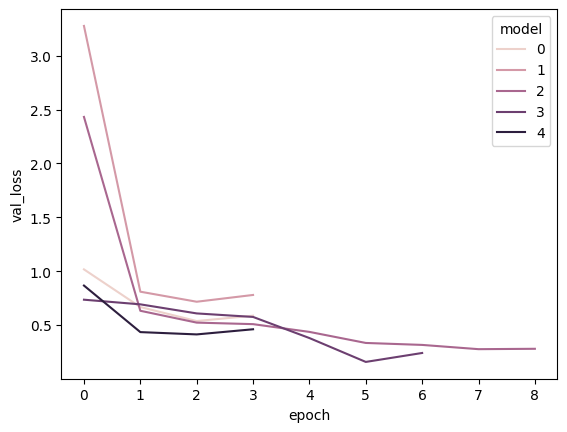

In [171]:
import seaborn as sns
sns.lineplot(
    data=df,
    x='epoch',
    y='val_loss',
    hue='model'
)

# qUCB

In [194]:
cands

tensor([[   3],
        [  15],
        [1657],
        [   1],
        [  64],
        [ 267],
        [  45],
        [  49],
        [5805],
        [ 338],
        [4288],
        [4960],
        [ 133],
        [ 406],
        [  11],
        [  63],
        [3296],
        [   0],
        [   2],
        [   4],
        [   5],
        [   6],
        [   7],
        [   8]])

In [151]:
pred_tensor = model.forward(cands)

In [152]:

mu  = pred_tensor.mean(0)                 # (N,)
std = pred_tensor.std(0)                  # (N,)
print(mu[:10], std[:10])
print("μ range:", float(mu.min()), float(mu.max()))
print("σ range:", float(std.min()), float(std.max()))

tensor([[ 4.1753],
        [12.9594],
        [ 5.5276],
        [ 7.9526],
        [ 9.8725]]) tensor([[1.6107],
        [1.5074],
        [0.9913],
        [0.7069],
        [1.2206]])
μ range: 4.175261974334717 12.959370613098145
σ range: 0.706923246383667 1.6106536388397217
